In [2]:
!pip install heyoka

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.4/102.4 MB 9.2 MB/s eta 0:00:0000:010:01


In [16]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
from scipy import signal
import time

In [3]:
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [53]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2)

In [13]:
print(pvars)

t=0.0, lambda1=0.24363402848677218, eta1=-0.0006914864975751438, rho1=-0.0, lambda2=1.5490392859050166, eta2=-0.0009112940308177825, rho2=-0.0, Lambda1=0.0023522794299155967, kappa1=0.002821900429229676, sigma1=0.0, Lambda2=0.0008532031901639505, kappa2=3.295225000838225e-06, sigma2=0.0


In [14]:
print(pham.H)

-C_{(0,0,-1,1,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2})*G*m1*m2*(eta1*eta2/(sqrt(\Lambda_{1,0})*sqrt(\Lambda_{2,0})) + kappa1*kappa2/(sqrt(\Lambda_{1,0})*sqrt(\Lambda_{2,0})))/a_{2,0} - C_{(0,0,0,0,-1,1)}^{(0,0,0,0),(0,0)}(\alpha_{1,2})*G*m1*m2*(rho1*rho2/(4*sqrt(\Lambda_{1,0})*sqrt(\Lambda_{2,0})) + sigma1*sigma2/(4*sqrt(\Lambda_{1,0})*sqrt(\Lambda_{2,0})))/a_{2,0} - C_{(0,0,0,0,0,0)}^{(0,0,0,1),(0,0)}(\alpha_{1,2})*G*m1*m2*(eta2**2 + kappa2**2)/(\Lambda_{2,0}*a_{2,0}) - C_{(0,0,0,0,0,0)}^{(0,0,1,0),(0,0)}(\alpha_{1,2})*G*m1*m2*(eta1**2 + kappa1**2)/(\Lambda_{1,0}*a_{2,0}) - C_{(0,0,0,0,0,0)}^{(0,1,0,0),(0,0)}(\alpha_{1,2})*G*m1*m2*(rho2**2/2 + sigma2**2/2)/(2*\Lambda_{2,0}*a_{2,0}) - C_{(0,0,0,0,0,0)}^{(1,0,0,0),(0,0)}(\alpha_{1,2})*G*m1*m2*(rho1**2/2 + sigma1**2/2)/(2*\Lambda_{1,0}*a_{2,0}) - C_{(2,-1,-1,0,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2})*G*m1*m2*(eta1*sin(lambda1 - 2*lambda2)/sqrt(\Lambda_{1,0}) + kappa1*cos(lambda1 - 2*lambda2)/sqrt(\Lambda_{1,0}))/a_{2,0} - C_{(2,-1,0,-1,0,0)}^{

In [15]:
print(pham.H.free_symbols)

{C_{(4,-2,-1,-1,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), mu2, C_{(0,0,0,0,0,0)}^{(0,0,0,1),(0,0)}(\alpha_{1,2}), Lambda2, G, C_{(2,-1,-1,0,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), C_{(4,-2,0,0,0,-2)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), C_{(0,0,0,0,0,0)}^{(0,0,1,0),(0,0)}(\alpha_{1,2}), lambda1, kappa1, sigma2, C_{(0,0,0,0,0,0)}^{(0,1,0,0),(0,0)}(\alpha_{1,2}), rho1, C_{(0,0,0,0,0,0)}^{(1,0,0,0),(0,0)}(\alpha_{1,2}), m1, M1, C_{(4,-2,0,0,-1,-1)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), C_{(0,0,-1,1,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), sigma1, mu1, \Lambda_{2,0}, C_{(4,-2,0,-2,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), lambda2, \Lambda_{1,0}, rho2, C_{(4,-2,-2,0,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), eta1, C_{(4,-2,0,0,-2,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), a_{2,0}, C_{(0,0,0,0,-1,1)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), eta2, m2, C_{(2,-1,0,-1,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}), kappa2, M2, Lambda1}


In [21]:
print(type(pham.H_params))
print(dict(pham.H_params))

<class 'celmech.hamiltonian.ParamDict'>
{G: 1.0, mu1: np.float64(0.0009935903962547195), m1: np.float64(0.0009945786), M1: np.float64(1.0009945786), \Lambda_{1,0}: np.float64(0.0023522794299155967), a_{1,0}: np.float64(5.59926891881355), \alpha_{1,2}: np.float64(0.6282596315668357), mu2: np.float64(0.00028575532055643806), m2: np.float64(0.000285837), M2: np.float64(1.000285837), \Lambda_{2,0}: np.float64(0.0008532031901639505), a_{2,0}: np.float64(8.912348712982503), C_{(0,0,0,0,0,0)}^{(0,0,0,1),(0,0)}(\alpha_{1,2}): 0.382936998527643, C_{(0,0,0,0,0,0)}^{(0,0,1,0),(0,0)}(\alpha_{1,2}): 0.382936998527643, C_{(0,0,0,0,0,0)}^{(0,1,0,0),(0,0)}(\alpha_{1,2}): -1.53174799411058, C_{(0,0,0,0,0,0)}^{(1,0,0,0),(0,0)}(\alpha_{1,2}): -1.53174799411058, C_{(0,0,-1,1,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}): -0.567406752948394, C_{(0,0,0,0,-1,1)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}): 3.06349598822116, C_{(2,-1,0,-1,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}): 0.418572166682581, C_{(2,-1,-1,0,0,0)}^{(0,0,0,0),(0

In [54]:
H_num = pham.H.subs(dict(pham.H_params))
print("Current Free symbols: " + str(H_num.free_symbols)) 

Current Free symbols: {sigma1, kappa2, kappa1, rho2, rho1, Lambda1, eta2, lambda2, Lambda2, lambda1, sigma2, eta1}


In [55]:
rho1,rho2,sigma1,sigma2 = sp.symbols('rho1 rho2 sigma1 sigma2')
H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})

lam1,lam2 = sp.symbols('lamba1 lambda2')
Lam1,Lam2 = sp.symbols('Lamba1 Lambda2')
eta1,eta2 = sp.symbols('eta1 eta2')
kap1, kap2 = sp.symbols('kappa1 kapp2')

In [56]:
sym_dict = {str(s): s for s in H_planar.free_symbols}
lam1 = sym_dict['lambda1']
lam2 = sym_dict['lambda2']
Lam1 = sym_dict['Lambda1']
Lam2 = sym_dict['Lambda2']
eta1 = sym_dict['eta1']
eta2 = sym_dict['eta2']
kap1 = sym_dict['kappa1']
kap2 = sym_dict['kappa2']

dLam1_dt = -sp.diff(H_planar, lam1)
dLam2_dt = -sp.diff(H_planar, lam2)
dlam1_dt =  sp.diff(H_planar, Lam1)
dlam2_dt =  sp.diff(H_planar, Lam2)

deta1_dt  = sp.diff(H_planar, kap1)
dkap1_dt  =  -sp.diff(H_planar, eta1)
deta2_dt  = sp.diff(H_planar, kap2)
dkap2_dt  =  -sp.diff(H_planar, eta2)

derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

In [8]:
for i in range(len(derivs)):
    print(sp.simplify(derivs[i]))

9.82846297495801e-10/Lambda1**3
9.07586283098301e-5*eta1*kappa1*cos(2*lambda1 - 4*lambda2) - 7.77144839345497e-7*eta1*cos(lambda1 - 2*lambda2) + 0.000533126907254472*eta2*kappa2*cos(2*lambda1 - 4*lambda2) + 4.5709818369841e-7*eta2*cos(lambda1 - 2*lambda2) + 7.77144839345497e-7*kappa1*sin(lambda1 - 2*lambda2) - 4.5709818369841e-7*kappa2*sin(lambda1 - 2*lambda2) + 4.53793141549151e-5*(eta1**2 - kappa1**2)*sin(2*lambda1 - 4*lambda2) + 0.000266563453627236*(eta2**2 - kappa2**2)*sin(2*lambda1 - 4*lambda2) + 0.000221287787986421*(-eta1*eta2 + kappa1*kappa2)*sin(2*lambda1 - 4*lambda2) - 0.000221287787986421*(eta1*kappa2 + eta2*kappa1)*cos(2*lambda1 - 4*lambda2)
2.33470071094001e-11/Lambda2**3
-0.00018151725661966*eta1*kappa1*cos(2*lambda1 - 4*lambda2) + 1.55428967869099e-6*eta1*cos(lambda1 - 2*lambda2) - 0.00106625381450894*eta2*kappa2*cos(2*lambda1 - 4*lambda2) - 9.1419636739682e-7*eta2*cos(lambda1 - 2*lambda2) - 1.55428967869099e-6*kappa1*sin(lambda1 - 2*lambda2) + 9.1419636739682e-7*kappa2

In [57]:
vars = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
func = sp.lambdify(vars,derivs,'numpy')

jup = pham.state.particles[1]
sat = pham.state.particles[2]

initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,jup.eta, jup.kappa, sat.eta, sat.kappa]
derivs_at_0 = func(*initial_conditions)

In [58]:
lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

eqs_hy = [hy.from_sympy(eq, {lam1: lam1_hy, Lam1: Lam1_hy,
                               lam2: lam2_hy, Lam2: Lam2_hy,
                               eta1: eta1_hy, kap1: kap1_hy,
                               eta2: eta2_hy, kap2: kap2_hy})
           for eq in derivs]

print(eqs_hy[0])

(9.8284629749580068e-10 / Lam1_hy**3.0000000000000000)


In [59]:
ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-12)

print(ta)

C++ datatype            : double
Tolerance               : 1e-12
High accuracy           : true
Compact mode            : false
Taylor order            : 15
Dimension               : 8
Time                    : 0
State                   : [0.24363402848677218, 0.0023522794299155967, 1.5490392859050166, 0.0008532031901639505, -0.0006914864975751438, 0.002821900429229676, -0.0009112940308177825, 3.295225000838225e-06]



In [60]:
times = np.linspace(0,1e7,int(1e5))*2*np.pi
e_sat = np.zeros(len(times))
pomega_sat = np.zeros(len(times))

start = time.perf_counter()
for i in range(len(times)):
    ta.propagate_until(times[i])
    L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
    e_sat[i] = get_ecc(kap, eta, L)
    pomega_sat[i] = get_pomega(kap, eta)
end = time.perf_counter()

print(end-start)

0.8272719619999407


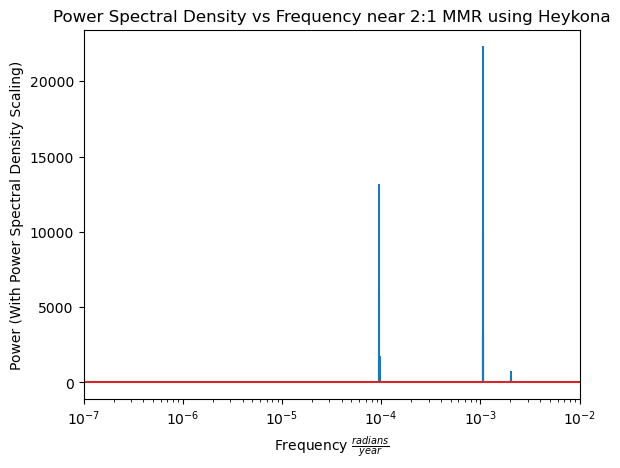

In [63]:
f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')
plt.show()

425.07778468000015


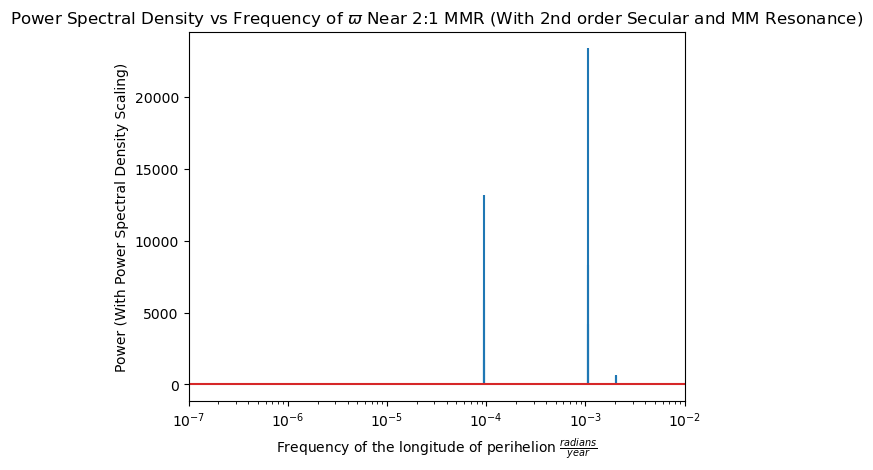

In [50]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2)

start = time.perf_counter()
for i in range(len(times)):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e
    long_peri_j[i] = pham.state.particles[1].pomega
    e_j[i] = pham.state.particles[1].e
end = time.perf_counter()

print(end-start)

f_cm,pxx_cm = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f_cm*2*np.pi,pxx_cm,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ Near 2:1 MMR (With 2nd order Secular and MM Resonance)')
plt.show()

In [64]:
print(f'Heyoka was {425.07778468000015/0.8272719619999407
 :.2f} times faster')

Heyoka was 513.83 times faster


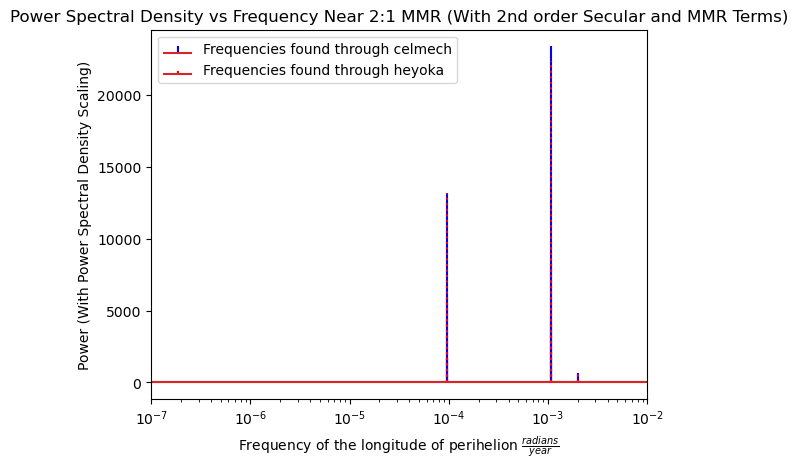

In [65]:
plt.stem(f_cm*2*np.pi,pxx_cm,markerfmt = "none",label = 'Frequencies found through celmech', linefmt = 'b-')
plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through heyoka', linefmt = 'r:')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency Near 2:1 MMR (With 2nd order Secular and MMR Terms)')
plt.legend()
plt.show()